# Calculate the Polarimetric Accuracy of the Model

Finally, you can calculate the theoretical uncertainties on measure the degree and angle of linear polarization from your data and model, $s_p$ and $s_{\chi}$. You do this by propagating together $s_{rel}$ and $s_{abs}$ with the DoLP and AoLP of a theoretical target. This accounts for the new fit from after the 2026 M3 recoat, so this is different from the McIntosh+2026 SPIE proceeding.

# Step 1: Load in $s_{rel}$ and $s_{abs}$

NOTE: This calculation was derived from Appendix E of the van Holstein 2020 SPHERE/IRDIS calibration. $s_{abs}$ includes effects from unpolarized internal calibrations via this derivation. However, these effects are often negligible due to double differencing. It is up to user discretion whether to set $s_{abs}=s_{sky}$ (as in the Hart et al. 2021 CHARIS calibration) or to do the procedure I do below, where I account for $s_{unpol}$ using the results from the fit in `CHARIS.minimize.minimize_onsky_unpol_july2025.ipynb`.

In [2]:
# Loading in calculations from global fit notebooks
import numpy as np

with open('s_rel.txt', 'r') as f:
    s_rel = [float(x) for x in f.read().splitlines()]

with open('s_sky.txt', 'r') as f:
    s_sky = [float(x) for x in f.read().splitlines()]

with open('s_unpol.txt', 'r') as f:
    s_unpol = [float(x) for x in f.read().splitlines()]

s_abs = np.hypot(s_sky, s_unpol)  # Calculate absolute polarimetric accuracy

# Step 2: Calculate $s_p$ and $s_{\chi}$

These are the errors introduced for the DoLP and AoLP from model uncertainty

In [3]:
from pyPolCal.fitting import calc_polarimetric_accuracy
# Calculating for a 1% polarized target
s_p, s_chi = calc_polarimetric_accuracy(s_abs,s_rel, p=1, chi_deg=50)
print(s_p)
print(s_chi)

[0.03472783 0.03462094 0.02999903 0.02760324 0.02271478 0.02696615
 0.02213776 0.02500842 0.01986835 0.02729214 0.02491005 0.02684358
 0.02597114 0.02852075 0.03192968 0.03383872 0.03697504 0.02632321
 0.02548837 0.04464323 0.07648509 1.12729313]
[ 0.8785824   0.90358704  0.80121506  0.75220925  0.59678811  0.7567098
  0.6219895   0.69912567  0.55029138  0.76469209  0.69297731  0.74921648
  0.72864329  0.80077844  0.90018709  0.95511777  1.04755375  0.74221506
  0.71973649  1.26707147  2.17451792 32.27766977]


Text(0, 0.5, '$s_p$ (%)')

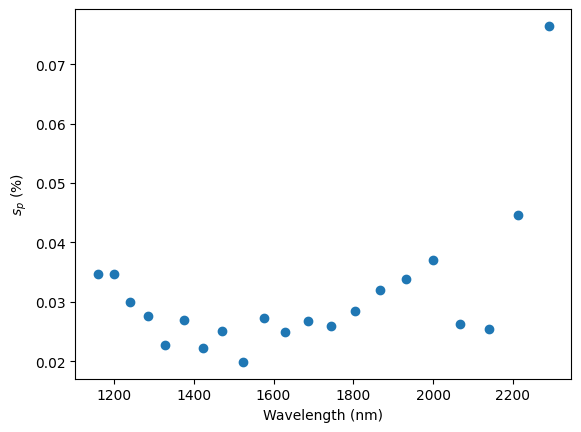

In [5]:
from pyPolCal.constants import wavelength_bins
import matplotlib.pyplot as plt

plt.scatter(wavelength_bins[:-1], s_p[:-1], label='s_p') # last bin is really noisy
plt.xlabel('Wavelength (nm)')
plt.ylabel('$s_p$ (%)')

Text(0, 0.5, '$s_{\\chi}$ ($^\\circ$)')

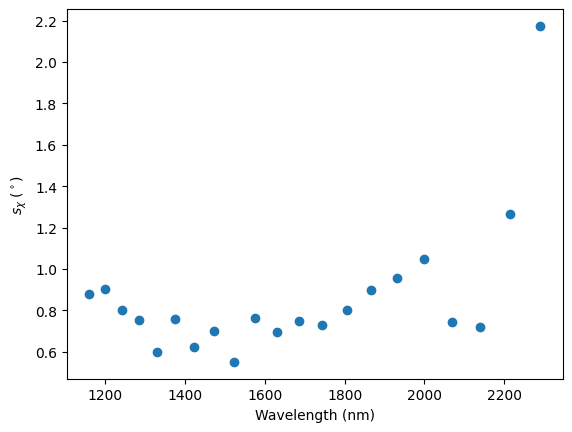

In [6]:
plt.scatter(wavelength_bins[:-1], s_chi[:-1], label='s_chi') # last bin is really noisy
plt.xlabel('Wavelength (nm)')
plt.ylabel('$s_{\chi}$ ($^\circ$)')